In [7]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Dropout(0.25),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.25),
    Dense(1, activation="sigmoid")   # Binary output
])


In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635,361 (21.50 MB)

 Trainable params: 5,635,361 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def train_generator(path):
    gen = ImageDataGenerator(
        rescale=1/255,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True
    )
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary"
    )



In [14]:
def test_generator(path):
    gen = ImageDataGenerator(rescale=1/255)
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary",
        shuffle=False   # IMPORTANT
    )


In [ ]:
trainingData   = train_generator("data/Training")
validationData = test_generator("data/Validation")
testingData    = test_generator("data/Testing")

print("Class indices:", trainingData.class_indices)



Found 5712 images belonging to 2 classes.
Found 645 images belonging to 2 classes.


Found 666 images belonging to 2 classes.
Class indices: {'notumor': 0, 'tumor': 1}


In [16]:
es = EarlyStopping(
    monitor="val_recall",
    patience=4,
    mode="max",
    verbose=1,
    restore_best_weights=True
)

mc = ModelCheckpoint(
    filepath="./bestModel.keras",
    monitor="val_recall",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [17]:
class_weight = {
    0: 1.0,   # notumor
    1: 3.0    # tumor
}



In [18]:
history = model.fit(
    trainingData,
    epochs=30,
    validation_data=validationData,
    callbacks=[es, mc],
    class_weight=class_weight
)


Epoch 1/30


2026-02-10 00:25:39.677260: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d0b3c00d100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-10 00:25:39.677310: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-10 00:25:39.743416: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-10 00:25:40.366497: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-10 00:25:40.526799: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-10 00:25:41.

  2/179 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 1.5194 - precision: 0.7802 - recall: 0.4215 

I0000 00:00:1770663349.625372  130346 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.7196 - precision: 0.8014 - recall: 0.9664
Epoch 1: val_recall improved from None to 0.89955, saving model to ./bestModel.keras

Epoch 1: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 59s 268ms/step - loss: 0.4580 - precision: 0.8567 - recall: 0.9820 - val_loss: 0.2222 - val_precision: 0.9805 - val_recall: 0.8996
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.2422 - precision: 0.9316 - recall: 0.9864
Epoch 2: val_recall did not improve from 0.89955
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - loss: 0.2239 - precision: 0.9341 - recall: 0.9852 - val_loss: 0.1963 - val_precision: 0.9877 - val_recall: 0.8996
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.2045 - precision: 0.9493 - recall: 0.9821
Epoch 3: val_recall improved from 0.89955 to 0.90179, saving model to ./bestModel.keras

Epoch 3: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step -

In [19]:
model = load_model("./bestModel.keras")

y_true = testingData.classes
y_prob = model.predict(testingData)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step


In [20]:
THRESHOLD = 0.3
y_pred = (y_prob >= THRESHOLD).astype(int).ravel()

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_true, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred,
    target_names=testingData.class_indices.keys()
))



CONFUSION MATRIX
[[195  13]
 [  0 458]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     notumor       1.00      0.94      0.97       208
       tumor       0.97      1.00      0.99       458

    accuracy                           0.98       666
   macro avg       0.99      0.97      0.98       666
weighted avg       0.98      0.98      0.98       666



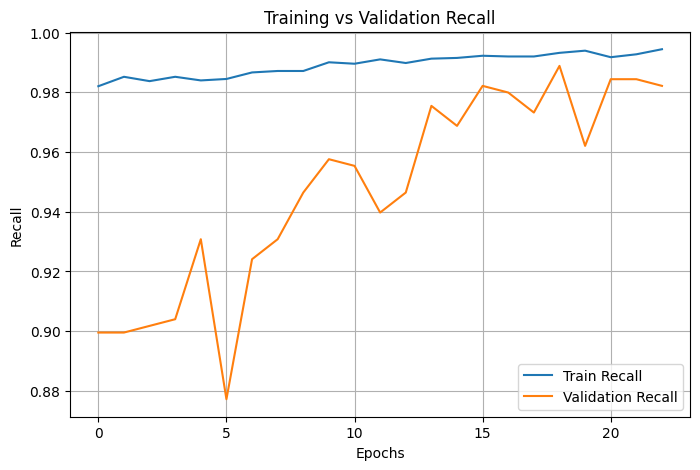

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.grid(True)
plt.show()


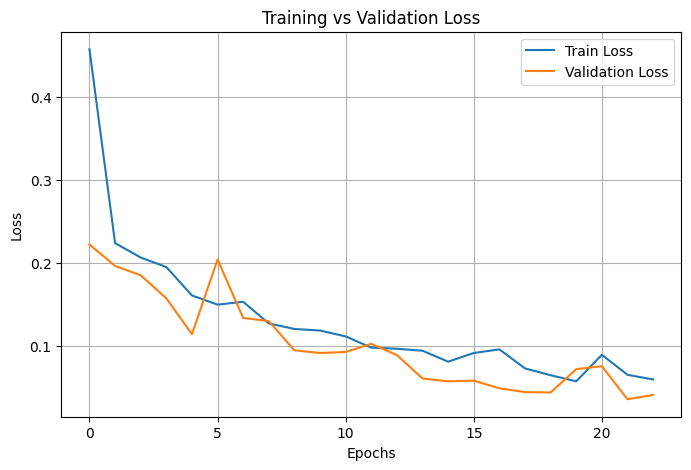

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


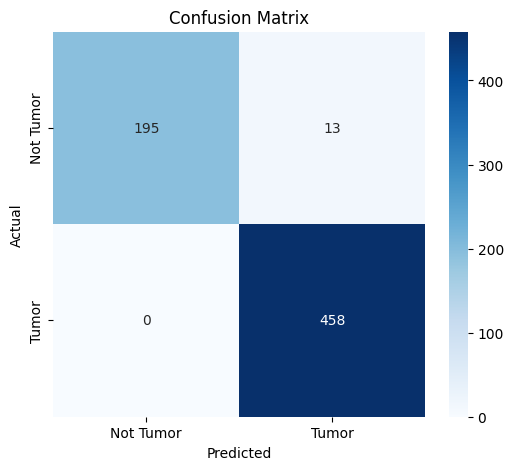

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Tumor', 'Tumor'],
            yticklabels=['Not Tumor', 'Tumor'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


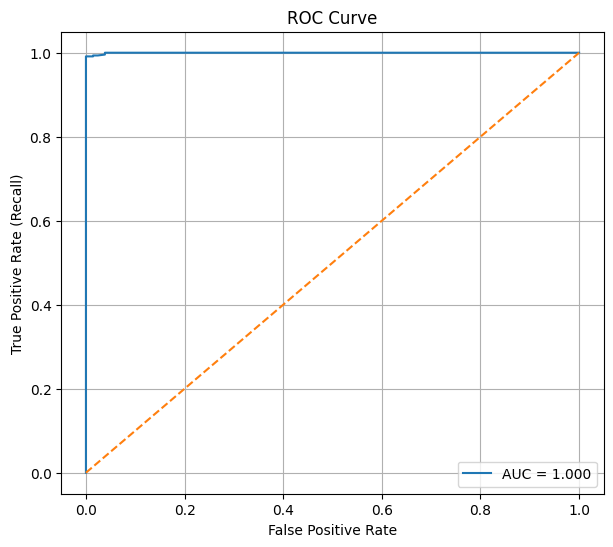

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
